In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("programmer3/cloud-resource-usage-dataset-for-anomaly-detection")

# print("Path to dataset files:", path)

In [2]:
from utils import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, make_scorer, recall_score, precision_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [3]:
W = 30                     
H = 10                     
TRAIN_SIZE = 0.8                   
RANDOM_STATE = 42

In [4]:
df = pd.read_csv("data/cloud_dataset.csv")

In [5]:
df.groupby("Workload_Type")["Anomaly_Label"].value_counts()

Workload_Type    Anomaly_Label
Backup           0                1457
Crypto_Mining    1                1257
                 0                 209
Database_Query   0                4296
Video_Streaming  0                2870
Web_Service      0                4311
Name: count, dtype: int64

In [6]:
df.Anomaly_Label.value_counts()

Anomaly_Label
0    13143
1     1257
Name: count, dtype: int64

In [7]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values(["User_ID", "Timestamp"])
df = df.reset_index(drop=True)

In [8]:
df, time_features = create_time_features(df)

In [9]:
df, ratio_features = create_ratio_features(df)

In [10]:
metrics = ["CPU_Usage","Memory_Usage","Disk_IO","Network_IO"]
df, rolling_features = extract_features(df, metrics, window=W)

In [11]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [12]:
all_features = time_features + ratio_features + rolling_features

In [13]:
df = df.drop(columns=["hour","dayofweek"])
all_features.remove("hour")
all_features.remove("dayofweek")

In [14]:
data = df[all_features].values.astype(np.float32)
labels = df["Anomaly_Label"].values.astype(int)

In [15]:
X = []
y = []
for t in range(W, len(df)-H):
    window = data[t-W:t]      
    future = labels[t:t+H]    

    label = 1 if future.sum() > 0 else 0

    X.append(window)
    y.append(label)
    
X = np.array(X)
y = np.array(y)

In [16]:
X = X.reshape(X.shape[0], -1)

In [17]:
# === 1) Split temporal en 3 bloques ===
n_samples = len(X)
train_end = int(n_samples * 0.6)   # 60% train
val_end   = int(n_samples * 0.8)   # 20% val, 20% test

X_train = X[:train_end]
y_train = y[:train_end]

X_val   = X[train_end:val_end]
y_val   = y[train_end:val_end]

X_test  = X[val_end:]
y_test  = y[val_end:]

# === 2) Scaling (fit solo en train) ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# === 3) Grid search solo sobre train ===
results = perform_grid_search(X_train_scaled, y_train)
# results = perform_grid_search(X_train_scaled, y_train, scoring="average_precision")
# results = perform_grid_search(
#     X_train_scaled, y_train,
#     model=XGBClassifier(random_state=42, scale_pos_weight=10, eval_metric='aucpr'),
#     param_grid={
#         'n_estimators': [100, 200],
#         'max_depth': [3, 5, 7],
#         'learning_rate': [0.05, 0.1],
#         'subsample': [0.8, 1.0],
#         'colsample_bytree': [0.8]
#     }
# )
# results = perform_grid_search(
#     X_train_scaled, y_train,
#     model=LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1),
#     param_grid={
#         'n_estimators': [100, 200],
#         'max_depth': [3, 5, -1],
#         'learning_rate': [0.05, 0.1],
#         'num_leaves': [31, 50],
#         'subsample': [0.8]
#     }
# )
best_model = results['best_model']

# === 4) Re-entrenar best_model en train+val (ya escalado) ===
X_trainval_scaled = np.vstack([X_train_scaled, X_val_scaled])
y_trainval = np.concatenate([y_train, y_val])

best_model.fit(X_trainval_scaled, y_trainval)

# === 5) Predicciones en test ===
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]
y_test_pred  = (y_test_proba >= 0.5).astype(int)

print("Classification Report (test, threshold=0.5):")
print(classification_report(y_test, y_test_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_test_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = auc(recall_curve, precision_curve)

print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test PR-AUC:  {pr_auc:.4f}")

# === 6) AUC en train+val para ver overfitting ===
y_trainval_proba = best_model.predict_proba(X_trainval_scaled)[:, 1]
trainval_auc = roc_auc_score(y_trainval, y_trainval_proba)
print(f"Train+Val AUC: {trainval_auc:.4f}, Test AUC: {roc_auc:.4f}")


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Classification Report (test, threshold=0.5):
              precision    recall  f1-score   support

           0     0.4420    0.2078    0.2827      1155
           1     0.6054    0.8225    0.6975      1707

    accuracy                         0.5744      2862
   macro avg     0.5237    0.5151    0.4901      2862
weighted avg     0.5395    0.5744    0.5301      2862

Test ROC-AUC: 0.5112
Test PR-AUC:  0.5913
Train+Val AUC: 0.9947, Test AUC: 0.5112


In [18]:
# Threshold selection usando incident-level recall en VALIDACIÓN
y_val_proba = best_model.predict_proba(X_val_scaled)[:, 1]
thresholds = np.linspace(0.1, 0.9, 9)

print("Incident-level threshold selection:")
for thr in thresholds:
    res = evaluate_alerts(y_val, y_val_proba, threshold=thr, H=H, step_duration=1.0)
    print(f"thr={thr:.2f}: incident_recall={res['incident_recall']:.3f}, "
          f"FP/unit_time={res['fp_per_unit_time']:.3f}")


Incident-level threshold selection:
thr=0.10: incident_recall=0.990, FP/unit_time=0.399
thr=0.20: incident_recall=0.990, FP/unit_time=0.376
thr=0.30: incident_recall=0.990, FP/unit_time=0.246
thr=0.40: incident_recall=0.838, FP/unit_time=0.102
thr=0.50: incident_recall=0.638, FP/unit_time=0.024
thr=0.60: incident_recall=0.486, FP/unit_time=0.005
thr=0.70: incident_recall=0.276, FP/unit_time=0.000
thr=0.80: incident_recall=0.048, FP/unit_time=0.000
thr=0.90: incident_recall=0.000, FP/unit_time=0.000


In [19]:
feature_names = []

for lag in range(W):
    for f in all_features:
        feature_names.append(f"{f}_t-{W-lag}")

In [20]:
importances = pd.Series(
    best_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print(importances.head(20))

CPU_Usage_range_30_t-30    0.003232
CPU_Usage_min_30_t-2       0.002870
Network_IO_min_30_t-12     0.002865
Network_IO_min_30_t-17     0.002849
Network_IO_min_30_t-14     0.002816
Network_IO_min_30_t-16     0.002687
Network_IO_min_30_t-15     0.002576
CPU_Usage_min_30_t-29      0.002543
Network_IO_min_30_t-4      0.002506
CPU_Usage_min_30_t-1       0.002502
Network_IO_range_30_t-5    0.002486
CPU_Usage_min_30_t-6       0.002393
CPU_Usage_range_30_t-28    0.002369
Network_IO_min_30_t-18     0.002244
Network_IO_min_30_t-5      0.002203
CPU_Usage_max_30_t-3       0.002200
Network_IO_min_30_t-1      0.002194
CPU_Usage_skew_30_t-12     0.002183
CPU_Usage_min_30_t-28      0.002136
CPU_Usage_max_30_t-8       0.002108
dtype: float64


In [21]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

In [22]:
best_thresh = 0
best_f1 = 0

for thresh in thresholds:

    y_pred_thresh = (y_pred_proba >= thresh).astype(int)

    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

    print(f"{thresh:.2f} | P={prec:.3f} R={rec:.3f} F1={f1:.3f}")

print("Best threshold:", best_thresh)


0.10 | P=0.596 R=1.000 F1=0.747
0.20 | P=0.596 R=1.000 F1=0.747
0.30 | P=0.596 R=1.000 F1=0.747
0.40 | P=0.596 R=1.000 F1=0.747
0.50 | P=0.596 R=0.999 F1=0.747
0.60 | P=0.727 R=0.009 F1=0.019
0.70 | P=0.000 R=0.000 F1=0.000
0.80 | P=0.000 R=0.000 F1=0.000
0.90 | P=0.000 R=0.000 F1=0.000
Best threshold: 0.1


Text(0.5, 1.0, 'Precision-Recall Curve')

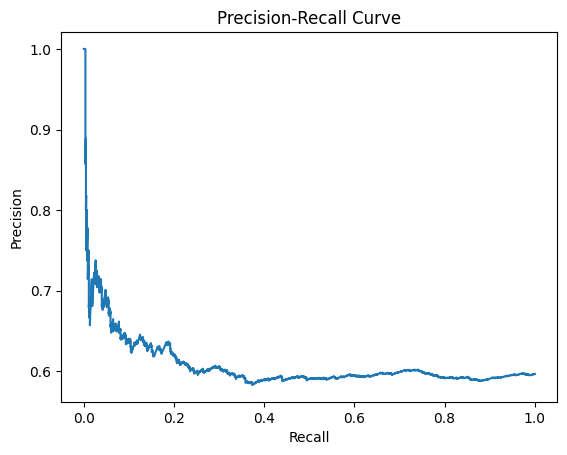

In [23]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

In [29]:
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Best threshold: {best_thresh:.2f}")
print(f"Best F1: {best_f1:.4f}")

# Incident recall at best threshold on validation
res = evaluate_alerts(y_val, y_val_proba, threshold=best_thresh, H=H, step_duration=1.0)
print(f"Incident Recall at best threshold: {res['incident_recall']:.3f}")
print(f"FP per unit time: {res['fp_per_unit_time']:.3f}")

ROC-AUC: 0.5112
PR-AUC: 0.5913
Best threshold: 0.10
Best F1: 0.7472
Incident Recall at best threshold: 0.990
FP per unit time: 0.399
